In [1]:
import pandas as pd
import numpy as np

data = {
    "Order_ID": range(101, 116),
    "Customer": ["Rahul", "Priya", "Asha", "Vijay", "Sneha",
                 "Arjun", "Meena", "Kiran", "Neha", "Ravi",
                 "Pooja", "Suresh", "Anil", "Divya", "Kavya"],

    "Category": ["Electronics", "Clothing", "Electronics", "Groceries", "Clothing",
                 "Electronics", "Groceries", "Clothing", "Electronics", "Groceries",
                 "Clothing", "Electronics", "Groceries", "Clothing", "Electronics"],

    "Price": [25000, 1500, 18000, 800, 2000,
              22000, 950, 1800, np.nan, 700,
              2500, 27000, 850, 2300, 19500],

    "Quantity": [1, 2, 1, 5, 2,
                 1, 4, 2, 1, 6,
                 np.nan, 1, 5, 2, 1],

    "City": ["Hyderabad", "Hyderabad", "Bangalore", "Chennai", "Bangalore",
             "Hyderabad", "Chennai", "Bangalore", "Hyderabad", "Chennai",
             "Hyderabad", "Bangalore", "Chennai", "Hyderabad", "Bangalore"],

    "Rating": [5, 4, 5, 3, 4,
               5, 3, np.nan, 4, 2,
               5, 5, 3, 4, 5]
}

df = pd.DataFrame(data).copy()

In [2]:
df

,Order_ID,Customer,Category,Price,Quantity,City,Rating
0,101,Rahul,Electronics,25000.0,1.0,Hyderabad,5.0
1,102,Priya,Clothing,1500.0,2.0,Hyderabad,4.0
2,103,Asha,Electronics,18000.0,1.0,Bangalore,5.0
3,104,Vijay,Groceries,800.0,5.0,Chennai,3.0
4,105,Sneha,Clothing,2000.0,2.0,Bangalore,4.0
5,106,Arjun,Electronics,22000.0,1.0,Hyderabad,5.0
6,107,Meena,Groceries,950.0,4.0,Chennai,3.0
7,108,Kiran,Clothing,1800.0,2.0,Bangalore,NaN
8,109,Neha,Electronics,NaN,1.0,Hyderabad,4.0
9,110,Ravi,Groceries,700.0,6.0,Chennai,2.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order_ID  15 non-null     int64  
 1   Customer  15 non-null     object 
 2   Category  15 non-null     object 
 3   Price     14 non-null     float64
 4   Quantity  14 non-null     float64
 5   City      15 non-null     object 
 6   Rating    14 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 972.0+ bytes


In [4]:
df.describe()

,Order_ID,Price,Quantity,Rating
count,15.000000,14.000000,14.000000,14.000000
mean,108.000000,8921.428571,2.428571,4.071429
std,4.472136,10567.543093,1.785165,0.997249
min,101.000000,700.000000,1.000000,2.000000
25%,104.500000,1087.500000,1.000000,3.250000
50%,108.000000,2150.000000,2.000000,4.000000
75%,111.500000,19125.000000,3.500000,5.000000
max,115.000000,27000.000000,6.000000,5.000000


In [5]:
df.isnull().sum()

Order_ID    0
Customer    0
Category    0
Price       1
Quantity    1
City        0
Rating      1
dtype: int64

In [6]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
dtype: bool

In [7]:
df = df.dropna(subset=["Price","Quantity"]).copy()

In [8]:
df["Rating"] = df["Rating"].fillna(df["Rating"].mean())

In [9]:
df["Revenue"] = df["Price"]*df["Quantity"]

In [10]:
df

,Order_ID,Customer,Category,Price,Quantity,City,Rating,Revenue
0,101,Rahul,Electronics,25000.0,1.0,Hyderabad,5.0,25000.0
1,102,Priya,Clothing,1500.0,2.0,Hyderabad,4.0,3000.0
2,103,Asha,Electronics,18000.0,1.0,Bangalore,5.0,18000.0
3,104,Vijay,Groceries,800.0,5.0,Chennai,3.0,4000.0
4,105,Sneha,Clothing,2000.0,2.0,Bangalore,4.0,4000.0
5,106,Arjun,Electronics,22000.0,1.0,Hyderabad,5.0,22000.0
6,107,Meena,Groceries,950.0,4.0,Chennai,3.0,3800.0
7,108,Kiran,Clothing,1800.0,2.0,Bangalore,4.0,3600.0
9,110,Ravi,Groceries,700.0,6.0,Chennai,2.0,4200.0
11,112,Suresh,Electronics,27000.0,1.0,Bangalore,5.0,27000.0


In [11]:
#tasks

#Which category generated the highest total sales?

highest_total_sales_by_cat = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

print(f"{highest_total_sales_by_cat.index[0]} made the highest total sales of {highest_total_sales_by_cat.values[0]}")


Electronics made the highest total sales of 111500.0


In [12]:
#Which city spent the most money?

highest_total_by_cities = df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

print(f"{highest_total_by_cities.index[0]} spent the most money of {highest_total_by_cities.values[0]}")

Bangalore spent the most money of 72100.0


In [13]:
# What is the average rating of each category?

avg_rating_cats = df.groupby("Category")["Rating"].mean()

print(avg_rating_cats)

Category
Clothing       4.00
Electronics    5.00
Groceries      2.75
Name: Rating, dtype: float64


In [14]:
# Which customer spent the most money?

person_spent_most_money = df.sort_values("Revenue" ,ascending=False)
print(f"person spent most money is {person_spent_most_money.iloc[0,1]}")

person spent most money is Suresh


In [15]:
# Which category has the highest average price?

highest_avg_price = df.groupby("Category")["Price"].mean().sort_values(ascending=False)
print(f"{highest_avg_price.index[0]} has highest average price of {highest_avg_price.values[0]} ")

Electronics has highest average price of 22300.0 


In [16]:
df

,Order_ID,Customer,Category,Price,Quantity,City,Rating,Revenue
0,101,Rahul,Electronics,25000.0,1.0,Hyderabad,5.0,25000.0
1,102,Priya,Clothing,1500.0,2.0,Hyderabad,4.0,3000.0
2,103,Asha,Electronics,18000.0,1.0,Bangalore,5.0,18000.0
3,104,Vijay,Groceries,800.0,5.0,Chennai,3.0,4000.0
4,105,Sneha,Clothing,2000.0,2.0,Bangalore,4.0,4000.0
5,106,Arjun,Electronics,22000.0,1.0,Hyderabad,5.0,22000.0
6,107,Meena,Groceries,950.0,4.0,Chennai,3.0,3800.0
7,108,Kiran,Clothing,1800.0,2.0,Bangalore,4.0,3600.0
9,110,Ravi,Groceries,700.0,6.0,Chennai,2.0,4200.0
11,112,Suresh,Electronics,27000.0,1.0,Bangalore,5.0,27000.0


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

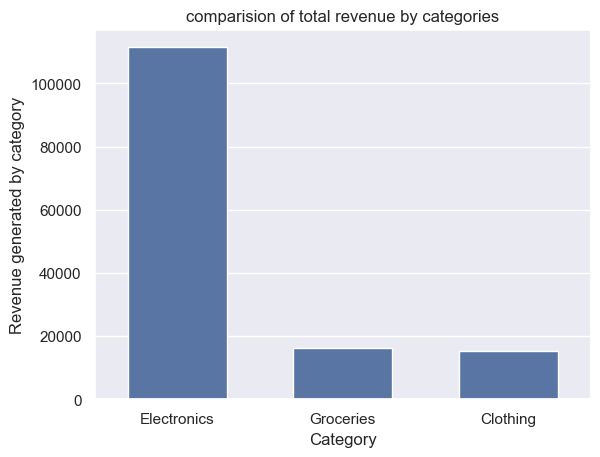

In [18]:
sns.set_theme(style="darkgrid")
sns.barplot(x=highest_total_sales_by_cat.index , y=highest_total_sales_by_cat.values , width=0.6)
plt.title("comparision of total revenue by categories")
plt.xlabel("Category")
plt.ylabel("Revenue generated by category")
plt.show()

#by observing the graph , i would say customers are showing instrest on highest price things like electronic devices 

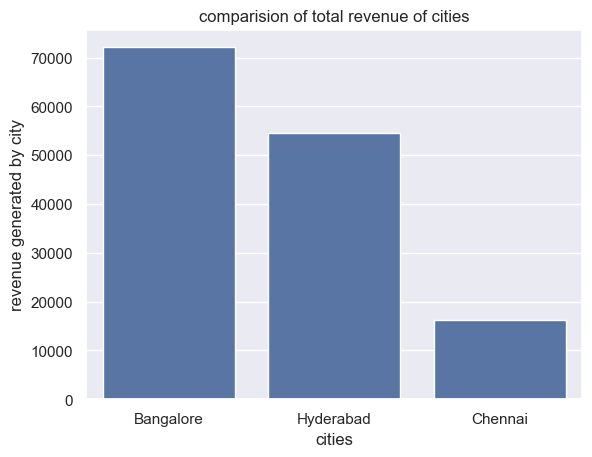

In [19]:
sns.barplot(x=highest_total_by_cities.index , y=highest_total_by_cities.values)
plt.title("comparision of total revenue of cities")
plt.xlabel("cities")
plt.ylabel("revenue generated by city")
plt.show()
#by observing the graph , i would say customers from bangalore are showing more intrest to buy things 

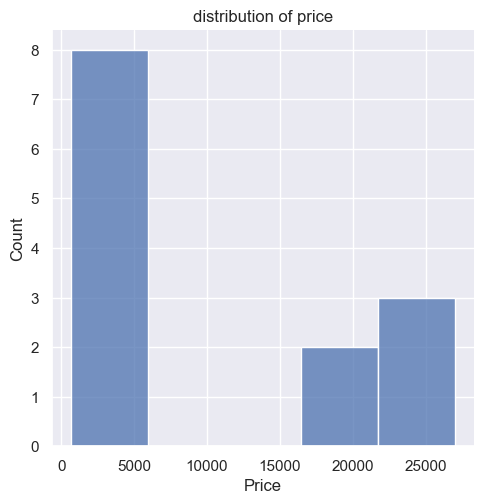

In [25]:
sns.displot(df,x="Price")
plt.title("distribution of price")
plt.show()

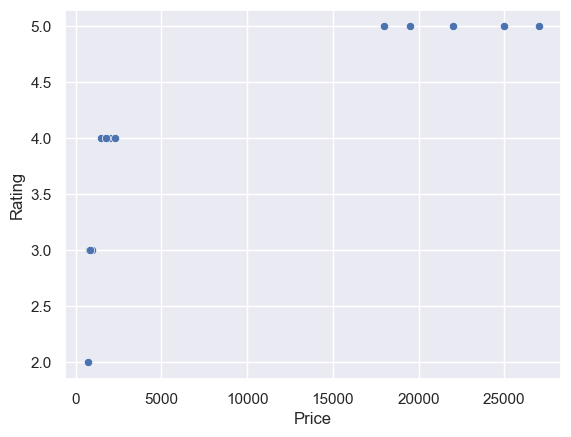

In [27]:
sns.scatterplot(x=df["Price"] , y=df["Rating"])
plt.show()

In [43]:
labels = [i for i in highest_total_sales_by_cat.index]
labels
revenue = [int(i)  for i in highest_total_sales_by_cat.values]
revenue
colors = ["#F5CF27","#27EBF5","#8B27F5"]
explode = [0.1,0,0]

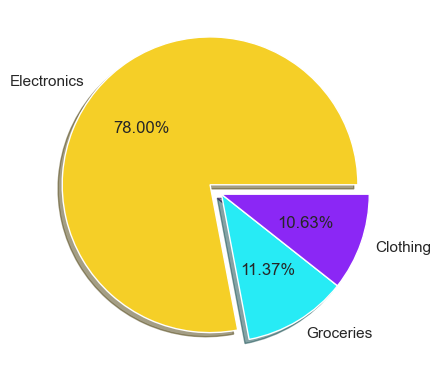

In [44]:
plt.pie(revenue,labels=labels,autopct="%1.2f%%",colors=colors,shadow=True,explode=explode)
plt.show()

In [ ]:
#insights
#1.by observing the graph , i would say customers are showing instrest on highest price things like electronic devices 
#2. people from bangalore are showing more intrest to buy products from the company
#3. by observing the data , i would say most people are purchasing products that are below 5000 worth
#4. products are above 15000 worth are getting 5 star rating
